Saved fig2_ba_gm_device.png


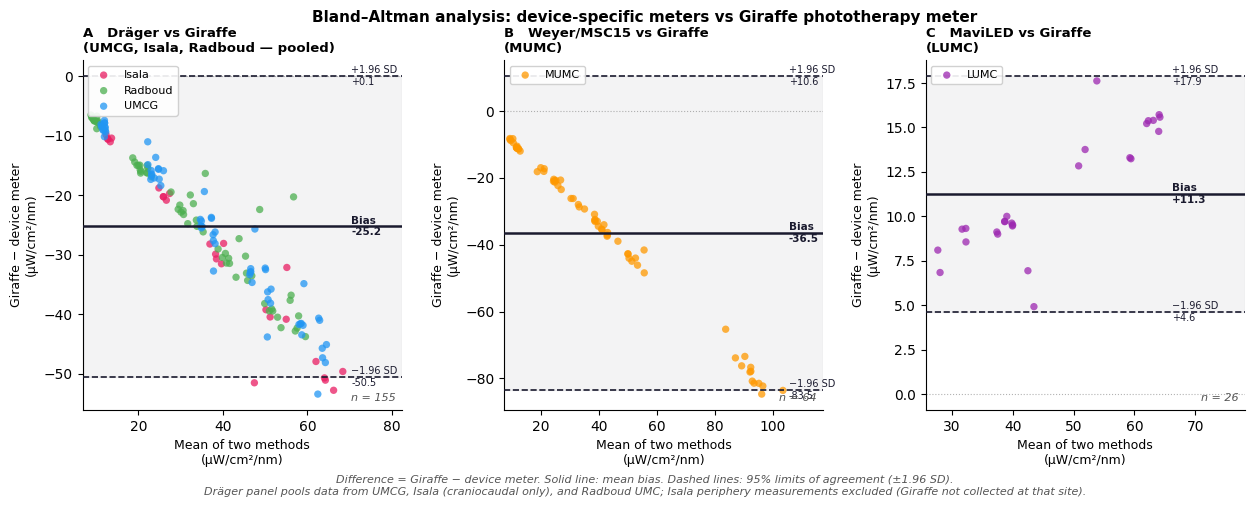

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('cleaned_data.csv')

keys = ['Hospital', 'Machine Type', 'Direction', 'Intensity', 'distance_cm', 'point_id']

g  = df[df['Meter Type'] == 'Giraffe'].copy()
d  = df[df['Meter Type'] == 'Dräger'].copy()
w  = df[df['Meter Type'] == 'Weyer'].copy()
mv = df[df['Meter Type'] == 'MaviLED'].copy()

# ── Pair 1: Dräger vs Giraffe (UMCG, Isala, Radboud — pooled) ────────────────
d_sites = ['UMCG', 'Isala', 'Radboud']
pair1 = pd.merge(
    g[g['Hospital'].isin(d_sites)][keys + ['irradiance']].rename(columns={'irradiance': 'giraffe'}),
    d[d['Hospital'].isin(d_sites)][keys + ['irradiance']].rename(columns={'irradiance': 'device'}),
    on=keys, how='inner'
)
pair1["diff"] = pair1["giraffe"] - pair1["device"]
pair1['mean'] = (pair1['device'] + pair1['giraffe']) / 2

# ── Pair 2: Weyer vs Giraffe (MUMC) ──────────────────────────────────────────
pair2 = pd.merge(
    g[g['Hospital'] == 'MUMC'][keys + ['irradiance']].rename(columns={'irradiance': 'giraffe'}),
    w[keys + ['irradiance']].rename(columns={'irradiance': 'device'}),
    on=keys, how='inner'
)
pair2["diff"] = pair2["giraffe"] - pair2["device"]
pair2['mean'] = (pair2['device'] + pair2['giraffe']) / 2

# ── Pair 3: MaviLED vs Giraffe (LUMC) ────────────────────────────────────────
pair3 = pd.merge(
    g[g['Hospital'] == 'LUMC'][keys + ['irradiance']].rename(columns={'irradiance': 'giraffe'}),
    mv[keys + ['irradiance']].rename(columns={'irradiance': 'device'}),
    on=keys, how='inner'
)
pair3["diff"] = pair3["giraffe"] - pair3["device"]
pair3['mean'] = (pair3['device'] + pair3['giraffe']) / 2

# ── Site colours ──────────────────────────────────────────────────────────────
site_colours = {
    'UMCG':    '#2196F3',
    'Isala':   '#E91E63',
    'Radboud': '#4CAF50',
    'MUMC':    '#FF9800',
    'LUMC':    '#9C27B0',
}

# ── BA stats helper ───────────────────────────────────────────────────────────
def ba_stats(diff):
    bias = diff.mean()
    sd   = diff.std()
    loa_lo = bias - 1.96 * sd
    loa_hi = bias + 1.96 * sd
    return bias, sd, loa_lo, loa_hi

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=0.32, top=0.88, bottom=0.18)

panels = [
    (axes[0], pair1, 'Hospital',
     'A   Dräger vs Giraffe\n(UMCG, Isala, Radboud — pooled)',
     site_colours),
    (axes[1], pair2, 'Hospital',
     'B   Weyer/MSC15 vs Giraffe\n(MUMC)',
     site_colours),
    (axes[2], pair3, 'Hospital',
     'C   MaviLED vs Giraffe\n(LUMC)',
     site_colours),
]

for ax, pair, hue_col, title, cmap in panels:
    bias, sd, loa_lo, loa_hi = ba_stats(pair['diff'])

    # Scatter — coloured by site
    for site, grp in pair.groupby(hue_col):
        col = cmap.get(site, '#888888')
        ax.scatter(grp['mean'], grp['diff'],
                   color=col, s=28, alpha=0.75, edgecolors='none',
                   label=site, zorder=3)

    # Bias and LoA lines
    xmin = pair['mean'].min() - 2
    xmax = pair['mean'].max() + 2

    ax.axhline(bias,   color='#1a1a2e', lw=1.8, ls='-',  zorder=4)
    ax.axhline(loa_hi, color='#1a1a2e', lw=1.2, ls='--', zorder=4)
    ax.axhline(loa_lo, color='#1a1a2e', lw=1.2, ls='--', zorder=4)
    ax.axhline(0,      color='gray',    lw=0.8, ls=':',  zorder=2, alpha=0.6)

    # Labels on lines (right side)
    ax.text(xmax, bias,   f'Bias\n{bias:+.1f}',   va='center', ha='left',
            fontsize=7.5, color='#1a1a2e', fontweight='bold')
    ax.text(xmax, loa_hi, f'+1.96 SD\n{loa_hi:+.1f}', va='center', ha='left',
            fontsize=7, color='#1a1a2e')
    ax.text(xmax, loa_lo, f'−1.96 SD\n{loa_lo:+.1f}', va='center', ha='left',
            fontsize=7, color='#1a1a2e')

    # Shaded LoA band
    ax.axhspan(loa_lo, loa_hi, alpha=0.05, color='#1a1a2e', zorder=1)

    ax.set_title(title, loc='left', fontsize=9.5, fontweight='bold', pad=6)
    ax.set_xlabel('Mean of two methods\n(µW/cm²/nm)', fontsize=9)
    ax.set_ylabel('Giraffe − device meter\n(µW/cm²/nm)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(xmin, xmax + 12)

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=8, framealpha=0.9,
              edgecolor='#cccccc', loc='upper left')

    # n annotation
    ax.text(0.98, 0.02, f'n = {len(pair)}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, color='#555555', style='italic')

fig.suptitle('Bland–Altman analysis: device-specific meters vs Giraffe phototherapy meter',
             fontsize=11, fontweight='bold', y=0.98)

CAPTION = (
    'Difference = Giraffe − device meter. Solid line: mean bias. Dashed lines: 95% limits of agreement (±1.96 SD).\n'
    'Dräger panel pools data from UMCG, Isala (craniocaudal only), and Radboud UMC; '
    'Isala periphery measurements excluded (Giraffe not collected at that site).'
)
fig.text(0.5, 0.01, CAPTION, ha='center', fontsize=8, color='#555555', style='italic')

plt.savefig('fig2_ba_gm_device.png', dpi=180, bbox_inches='tight', facecolor='white')
print("Saved fig2_ba_gm_device.png")
plt.show()
plt.close(fig)
